# Урок 1.4. Переобучение, смещение и разброс, валидация

**Интерактивная версия:** `lessons/lesson_1_4/web/index.html`

После урока вы сможете:
- распознавать недообучение и переобучение по ошибкам на обучении и на новых данных;
- объяснить, почему ошибка на обучении занижена на $2p\sigma^2/n$, и оценить уровень шума;
- разложить ошибку оценки и модели на смещение², разброс и шум и понимать, почему сжатие выгодно;
- читать кривые обучения и понимать роль усреднения и ранней остановки;
- организовать валидацию и кросс-валидацию без утечек, в том числе для временных рядов.

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "shared" / "python" / "gbcourse").is_dir())
sys.path.insert(0, str(ROOT / "shared" / "python"))

import matplotlib.pyplot as plt
import numpy as np

from gbcourse import GBRegressor, RegressionTree, datasets, style
from gbcourse.metrics import mse
from gbcourse.plotting import plot_data, plot_truth, use_course_style
from gbcourse.rng import Mulberry32

use_course_style()
NOISE2 = 0.35**2

## 1. U-кривая: обучение против новых данных

40 обучающих точек синуса и 400 новых. Ошибка на обучении падает всегда, на новых данных — до поры.

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


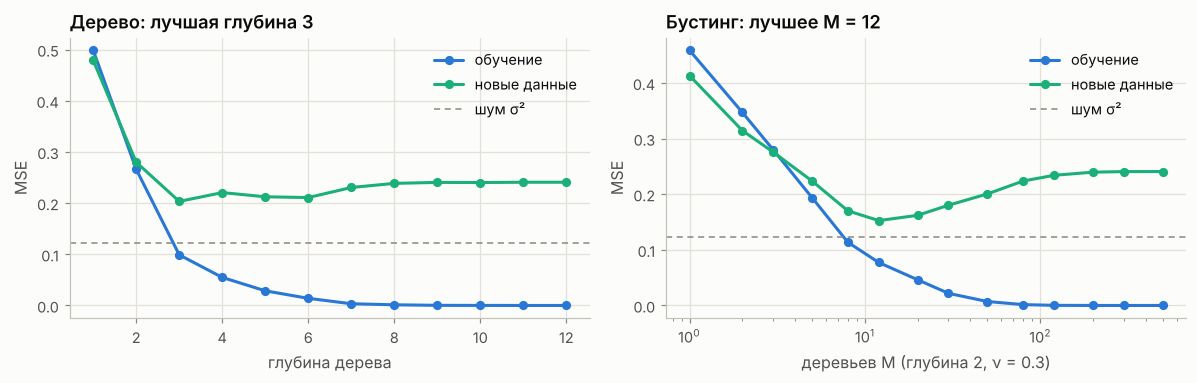

дерево: лучшая глубина 3 (MSE 0.203); глубина 12 — обучение 0.0000, новые 0.241
бустинг: лучшее M = 12 (MSE 0.153); M = 500 — обучение 0.0000, новые 0.241


In [2]:
X, y = datasets.regression_1d(kind="sine", n=40, noise=0.35, seed=2)
Xt, yt = datasets.regression_1d(kind="sine", n=400, noise=0.35, seed=102)
depths = range(1, 13)
tr = [mse(y, RegressionTree(max_depth=d).fit(X, -y).predict(X)) for d in depths]
te = [mse(yt, RegressionTree(max_depth=d).fit(X, -y).predict(Xt)) for d in depths]
gb = GBRegressor(n_estimators=500, learning_rate=0.3, max_depth=2).fit(X, y)
Ms = [1, 2, 3, 5, 8, 12, 20, 30, 50, 80, 120, 200, 300, 500]
gtr = [mse(y, gb.predict(X, n_iter=m)) for m in Ms]
gte = [mse(yt, gb.predict(Xt, n_iter=m)) for m in Ms]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].plot(depths, tr, marker="o", color=style.ROLE["train"], label="обучение")
axes[0].plot(depths, te, marker="o", color=style.ROLE["test"], label="новые данные")
axes[0].set(xlabel="глубина дерева", ylabel="MSE", title=f"Дерево: лучшая глубина {depths[int(np.argmin(te))]}")
axes[1].semilogx(Ms, gtr, marker="o", color=style.ROLE["train"], label="обучение")
axes[1].semilogx(Ms, gte, marker="o", color=style.ROLE["test"], label="новые данные")
axes[1].set(xlabel="деревьев M (глубина 2, ν = 0.3)", ylabel="MSE", title=f"Бустинг: лучшее M = {Ms[int(np.argmin(gte))]}")
for ax in axes:
    ax.axhline(NOISE2, color=style.MUTED, ls=(0, (4, 3)), lw=1, label="шум σ²")
    ax.legend()
fig.tight_layout()
plt.show()
print(f"дерево: лучшая глубина {depths[int(np.argmin(te))]} (MSE {min(te):.3f}); глубина 12 — обучение {tr[-1]:.4f}, новые {te[-1]:.3f}")
print(f"бустинг: лучшее M = {Ms[int(np.argmin(gte))]} (MSE {min(gte):.3f}); M = 500 — обучение {gtr[-1]:.4f}, новые {gte[-1]:.3f}")

## 2. Насколько занижена ошибка на обучении

Модель-константа (среднее $n = 4$ ответов, $\sigma^2 = 1$): ошибка на обучении $\sigma^2(n-1)/n = 0.75$,
на новом объекте $\sigma^2(n+1)/n = 1.25$. Проверим симуляцией.

In [3]:
r = Mulberry32(3)
tr_c, te_c = [], []
for _ in range(20000):
    e = np.array([r.normal() for _ in range(4)])
    tr_c.append(np.mean((e - e.mean()) ** 2))
    te_c.append((r.normal() - e.mean()) ** 2)
print(f"константа, n = 4: обучение {np.mean(tr_c):.3f} (формула 0.75), новый объект {np.mean(te_c):.3f} (формула 1.25)")

константа, n = 4: обучение 0.756 (формула 0.75), новый объект 1.239 (формула 1.25)


Общее правило для $p$ параметров, подобранных МНК: разрыв $2p\sigma^2/n$. Модель из $p$ корзин на 40 точках
против дерева: дерево выбирает пороги по ответам, и его «эффективных» параметров больше, чем листьев.

 8 корзин: обучение 0.157  новый шум 0.209  разрыв 0.052  2pσ²/n = 0.049
20 корзин: обучение 0.068  новый шум 0.193  разрыв 0.125  2pσ²/n = 0.122


40 корзин: обучение 0.000  новый шум 0.242  разрыв 0.242  2pσ²/n = 0.245


дерево глубины 1: листьев 2.0, разрыв 0.038, эффективных параметров 6.2
дерево глубины 2: листьев 4.0, разрыв 0.084, эффективных параметров 13.7
дерево глубины 3: листьев 7.8, разрыв 0.122, эффективных параметров 20.0


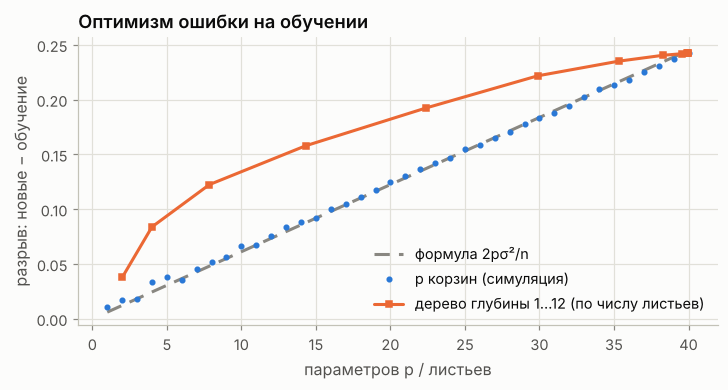

In [4]:
n_o, sims, sig = 40, 200, 0.35
x_o = (np.arange(n_o) + 0.5) * 10 / n_o
X_o, f_o = x_o.reshape(-1, 1), np.sin(x_o)
r = Mulberry32(1)
E1, E2 = [], []
for _ in range(sims):
    E1.append([r.normal() for _ in range(n_o)])
    E2.append([r.normal() for _ in range(n_o)])
E1, E2 = np.array(E1), np.array(E2)


def bins_predict(yv, p):
    b = (np.arange(n_o) * p) // n_o
    return (np.bincount(b, yv) / np.bincount(b))[b]


ps = np.arange(1, n_o + 1)
gap_bins = []
for p in ps:
    tr_ = np.mean([mse(f_o + sig * E1[k], bins_predict(f_o + sig * E1[k], p)) for k in range(sims)])
    te_ = np.mean([mse(f_o + sig * E2[k], bins_predict(f_o + sig * E1[k], p)) for k in range(sims)])
    gap_bins.append(te_ - tr_)
    if p in (8, 20, 40):
        print(f"{p:2d} корзин: обучение {tr_:.3f}  новый шум {te_:.3f}  разрыв {te_ - tr_:.3f}  2pσ²/n = {2 * p * sig**2 / n_o:.3f}")

tree_depths = range(1, 13)
gap_tree, leaves = [], []
for d in tree_depths:
    tr_, te_, lv = [], [], []
    for k in range(sims):
        pred = RegressionTree(max_depth=d).fit(X_o, -(f_o + sig * E1[k])).predict(X_o)
        tr_.append(mse(f_o + sig * E1[k], pred))
        te_.append(mse(f_o + sig * E2[k], pred))
        lv.append(len(np.unique(pred)))
    gap_tree.append(np.mean(te_) - np.mean(tr_))
    leaves.append(np.mean(lv))
for d in (1, 2, 3):
    g = gap_tree[d - 1]
    print(f"дерево глубины {d}: листьев {leaves[d - 1]:.1f}, разрыв {g:.3f}, эффективных параметров {g * n_o / (2 * sig**2):.1f}")

fig, ax = plt.subplots(figsize=(7.5, 3.4))
ax.plot(ps, 2 * ps * sig**2 / n_o, color=style.MUTED, ls=(0, (5, 3)), label="формула 2pσ²/n")
ax.plot(ps, gap_bins, "o", ms=3, color=style.BLUE, label="p корзин (симуляция)")
ax.plot(leaves, gap_tree, "s-", ms=4, color=style.ORANGE, label="дерево глубины 1…12 (по числу листьев)")
ax.set(xlabel="параметров p / листьев", ylabel="разрыв: новые − обучение", title="Оптимизм ошибки на обучении")
ax.legend()
plt.show()

Оценка шума по соседям: $\hat\sigma^2 = \frac{1}{2(n-1)}\sum (y_{i+1} - y_i)^2$ (точки упорядочены по $x$).

In [5]:
for n_s, noise_s, seed_s in ((300, 0.4, 7), (40, 0.35, 2)):
    _, ys_ = datasets.regression_1d(kind="sine", n=n_s, noise=noise_s, seed=seed_s)
    print(f"n = {n_s}: оценка шума {np.mean(np.diff(ys_) ** 2) / 2:.3f}, истинный σ² = {noise_s**2:.4f}")

n = 300: оценка шума 0.169, истинный σ² = 0.1600
n = 40: оценка шума 0.188, истинный σ² = 0.1225


## 3. Смещение и разброс одного числа: сжатие значения листа

В листе $n = 4$ остатка $\mu + \varepsilon$, $\mu = 1$, $\sigma = 2$. Сжатое значение $c\bar r$, $c = n/(n + \lambda)$:
смещение² $(1-c)^2\mu^2$, разброс $c^2\sigma^2/n$. Лучшее $\lambda^* = \sigma^2/\mu^2 = 4$.

λ =  0: формула 1.000   симуляция 1.002
λ =  1: формула 0.680   симуляция 0.681
λ =  4: формула 0.500   симуляция 0.499
λ = 10: формула 0.592   симуляция 0.591


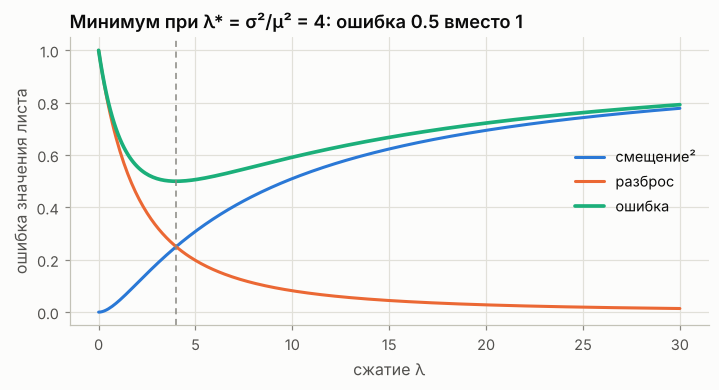

In [6]:
mu, sg, m_leaf = 1.0, 2.0, 4
lams = np.linspace(0, 30, 301)
cs = m_leaf / (m_leaf + lams)
b2_l, v_l = ((1 - cs) * mu) ** 2, cs**2 * sg**2 / m_leaf
r = Mulberry32(7)
means = np.array([np.mean([mu + sg * r.normal() for _ in range(m_leaf)]) for _ in range(20000)])
for lam in (0, 1, 4, 10):
    c = m_leaf / (m_leaf + lam)
    print(f"λ = {lam:2d}: формула {((1 - c) * mu) ** 2 + c**2 * sg**2 / m_leaf:.3f}   симуляция {np.mean((c * means - mu) ** 2):.3f}")

fig, ax = plt.subplots(figsize=(7.5, 3.4))
ax.plot(lams, b2_l, color=style.BLUE, label="смещение²")
ax.plot(lams, v_l, color=style.ORANGE, label="разброс")
ax.plot(lams, b2_l + v_l, color=style.AQUA, lw=2.4, label="ошибка")
ax.axvline(sg**2 / mu**2, color=style.MUTED, ls=(0, (4, 3)), lw=1)
ax.set(xlabel="сжатие λ", ylabel="ошибка значения листа", title="Минимум при λ* = σ²/μ² = 4: ошибка 0.5 вместо 1")
ax.legend()
plt.show()

## 4. Мишень: смещение² + разброс = средний квадрат промаха

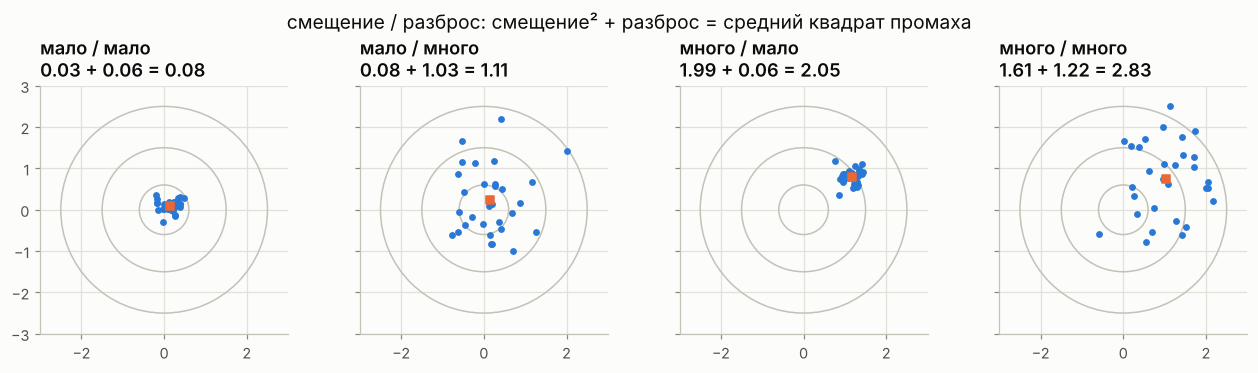

In [7]:
rng = Mulberry32(1)
fig, axes = plt.subplots(1, 4, figsize=(12, 3.2), sharex=True, sharey=True)
for ax, (bias, spread, title) in zip(axes, [(0.1, 0.25, "мало / мало"), (0.1, 1.1, "мало / много"), (1.4, 0.25, "много / мало"), (1.4, 1.1, "много / много")]):
    mu = bias * np.array([np.cos(np.radians(35)), np.sin(np.radians(35))])
    shots = np.array([[mu[0] + spread / np.sqrt(2) * rng.normal(), mu[1] + spread / np.sqrt(2) * rng.normal()] for _ in range(30)])
    mean = shots.mean(0)
    b2, var, msq = np.sum(mean**2), np.mean(np.sum((shots - mean) ** 2, 1)), np.mean(np.sum(shots**2, 1))
    for r in (2.5, 1.5, 0.6):
        ax.add_patch(plt.Circle((0, 0), r, fill=False, color=style.AXIS))
    ax.scatter(shots[:, 0], shots[:, 1], s=12, color=style.BLUE)
    ax.scatter([mean[0]], [mean[1]], marker="s", color=style.ORANGE, zorder=3)
    ax.set(title=f"{title}\n{b2:.2f} + {var:.2f} = {msq:.2f}", aspect="equal", xlim=(-3, 3), ylim=(-3, 3))
fig.suptitle("смещение / разброс: смещение² + разброс = средний квадрат промаха")
fig.tight_layout()
plt.show()

## 5. Разложение ошибки на 30 обучающих выборках

глубина  1: смещение² 0.301  разброс 0.078  ожидаемая ошибка 0.501
глубина  2: смещение² 0.083  разброс 0.110  ожидаемая ошибка 0.315
глубина  3: смещение² 0.025  разброс 0.122  ожидаемая ошибка 0.269
глубина  4: смещение² 0.013  разброс 0.126  ожидаемая ошибка 0.261
глубина  5: смещение² 0.012  разброс 0.132  ожидаемая ошибка 0.267


глубина  6: смещение² 0.012  разброс 0.141  ожидаемая ошибка 0.276
глубина  7: смещение² 0.012  разброс 0.143  ожидаемая ошибка 0.278
глубина  8: смещение² 0.012  разброс 0.145  ожидаемая ошибка 0.280


глубина  9: смещение² 0.012  разброс 0.145  ожидаемая ошибка 0.280
глубина 10: смещение² 0.012  разброс 0.145  ожидаемая ошибка 0.280


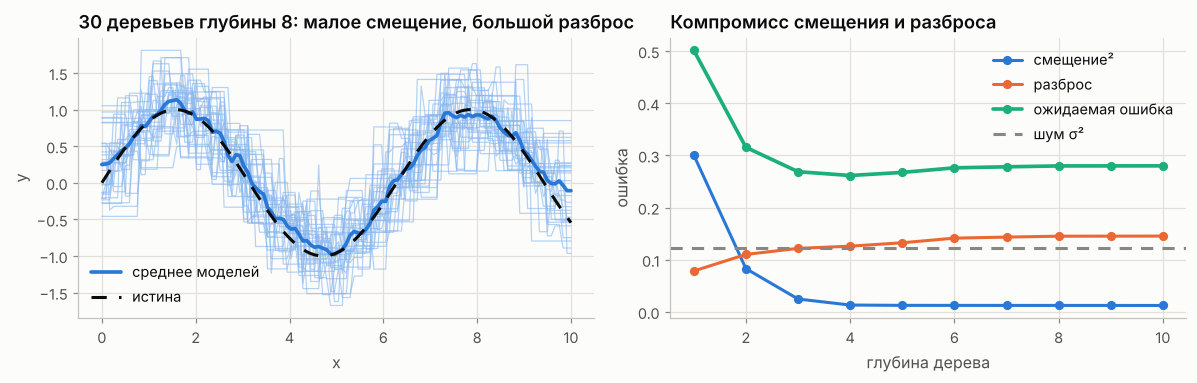

In [8]:
grid = np.linspace(0, 10, 120).reshape(-1, 1)
truth = np.sin(grid[:, 0])


def decompose(fit_predict, n: int = 30, B: int = 30):
    preds = np.array([fit_predict(*datasets.regression_1d(kind="sine", n=n, noise=0.35, seed=s)) for s in range(1, B + 1)])
    return np.mean((preds.mean(0) - truth) ** 2), np.mean(preds.var(0)), preds


rows = []
for d in range(1, 11):
    b2, v, _ = decompose(lambda X, y, d=d: RegressionTree(max_depth=d).fit(X, -y).predict(grid))
    rows.append((d, b2, v))
    print(f"глубина {d:2d}: смещение² {b2:.3f}  разброс {v:.3f}  ожидаемая ошибка {b2 + v + NOISE2:.3f}")
rows = np.array(rows)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
_, _, preds = decompose(lambda X, y: RegressionTree(max_depth=8).fit(X, -y).predict(grid))
axes[0].plot(grid[:, 0], preds.T, color=style.ROLE["model_prev"], lw=0.8, alpha=0.6)
axes[0].plot(grid[:, 0], preds.mean(0), color=style.BLUE, lw=2.4, label="среднее моделей")
axes[0].plot(grid[:, 0], truth, color=style.INK, ls=(0, (5, 4)), label="истина")
axes[0].set(title="30 деревьев глубины 8: малое смещение, большой разброс", xlabel="x", ylabel="y")
axes[0].legend()
axes[1].plot(rows[:, 0], rows[:, 1], marker="o", color=style.BLUE, label="смещение²")
axes[1].plot(rows[:, 0], rows[:, 2], marker="o", color=style.ORANGE, label="разброс")
axes[1].plot(rows[:, 0], rows[:, 1] + rows[:, 2] + NOISE2, marker="o", color=style.AQUA, lw=2.4, label="ожидаемая ошибка")
axes[1].axhline(NOISE2, color=style.MUTED, ls=(0, (4, 3)), label="шум σ²")
axes[1].set(xlabel="глубина дерева", ylabel="ошибка", title="Компромисс смещения и разброса")
axes[1].legend()
fig.tight_layout()
plt.show()

Проверим разложение напрямую: средняя ошибка на новых данных должна совпасть с суммой смещения², разброса и шума.

In [9]:
Xn, yn = datasets.regression_1d(kind="sine", n=4000, noise=0.35, seed=999)
for d in (1, 4, 10):
    errs = []
    for s in range(1, 31):
        Xs, ys = datasets.regression_1d(kind="sine", n=30, noise=0.35, seed=s)
        errs.append(mse(yn, RegressionTree(max_depth=d).fit(Xs, -ys).predict(Xn)))
    b2, v, _ = decompose(lambda X, y, d=d: RegressionTree(max_depth=d).fit(X, -y).predict(grid))
    print(f"глубина {d:2d}: средняя ошибка на новых {np.mean(errs):.3f}  ≈  смещение² + разброс + шум = {b2 + v + NOISE2:.3f}")

глубина  1: средняя ошибка на новых 0.508  ≈  смещение² + разброс + шум = 0.501
глубина  4: средняя ошибка на новых 0.265  ≈  смещение² + разброс + шум = 0.261


глубина 10: средняя ошибка на новых 0.283  ≈  смещение² + разброс + шум = 0.280


Где по оси $x$ сосредоточены смещение и разброс: у пня смещение — у дна синуса, у дерева глубины 4 разброс — у краёв.

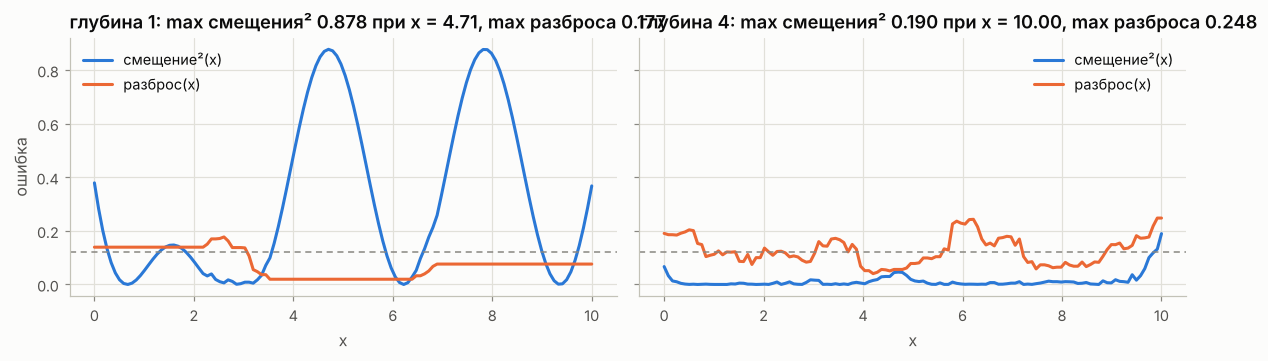

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4), sharey=True)
for ax, d in zip(axes, (1, 4)):
    _, _, P = decompose(lambda X, y, d=d: RegressionTree(max_depth=d).fit(X, -y).predict(grid))
    b2x, vx = (P.mean(0) - truth) ** 2, P.var(0)
    ax.plot(grid[:, 0], b2x, color=style.BLUE, label="смещение²(x)")
    ax.plot(grid[:, 0], vx, color=style.ORANGE, label="разброс(x)")
    ax.axhline(NOISE2, color=style.MUTED, ls=(0, (4, 3)), lw=1)
    ax.set(xlabel="x", title=f"глубина {d}: max смещения² {b2x.max():.3f} при x = {grid[b2x.argmax(), 0]:.2f}, max разброса {vx.max():.3f}")
    ax.legend()
axes[0].set_ylabel("ошибка")
fig.tight_layout()
plt.show()

## 6. Кривые обучения

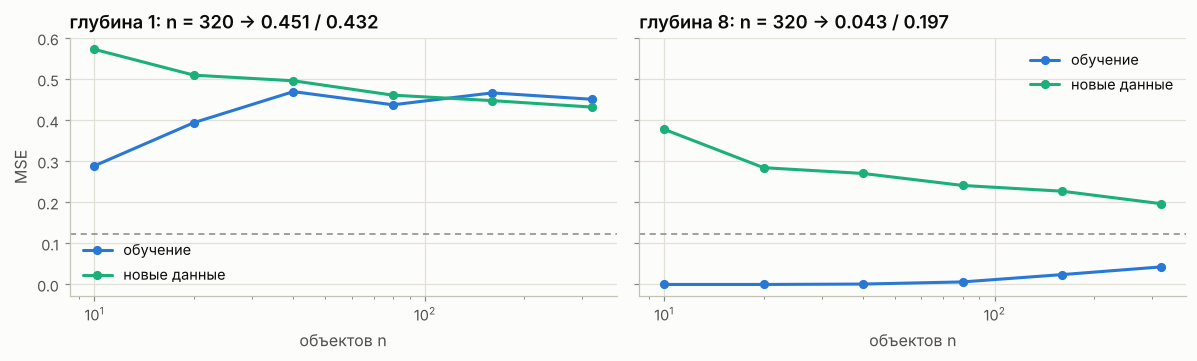

In [11]:
Xbig, ybig = datasets.regression_1d(kind="sine", n=500, noise=0.35, seed=999)
ns = [10, 20, 40, 80, 160, 320]
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4), sharey=True)
for ax, d in zip(axes, (1, 8)):
    tr_, te_ = [], []
    for n in ns:
        a, b = [], []
        for s in range(1, 11):
            Xs, ys = datasets.regression_1d(kind="sine", n=n, noise=0.35, seed=s)
            t = RegressionTree(max_depth=d).fit(Xs, -ys)
            a.append(mse(ys, t.predict(Xs)))
            b.append(mse(ybig, t.predict(Xbig)))
        tr_.append(np.mean(a))
        te_.append(np.mean(b))
    ax.semilogx(ns, tr_, marker="o", color=style.ROLE["train"], label="обучение")
    ax.semilogx(ns, te_, marker="o", color=style.ROLE["test"], label="новые данные")
    ax.axhline(NOISE2, color=style.MUTED, ls=(0, (4, 3)), lw=1)
    ax.set(xlabel="объектов n", title=f"глубина {d}: n = 320 → {tr_[-1]:.3f} / {te_[-1]:.3f}")
    ax.legend()
axes[0].set_ylabel("MSE")
fig.tight_layout()
plt.show()

## 7. Усреднение коррелированных моделей

$\operatorname{Var}(\text{среднее } B) = \rho\sigma^2 + (1-\rho)\sigma^2/B$.

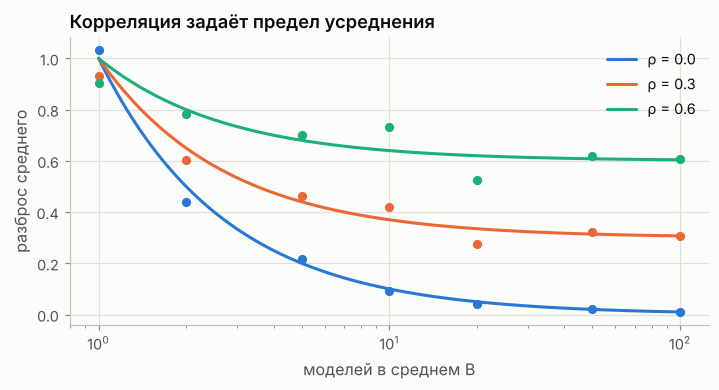

In [12]:
Bs = [1, 2, 5, 10, 20, 50, 100]
fig, ax = plt.subplots(figsize=(7.5, 3.4))
for rho, color in zip((0.0, 0.3, 0.6), style.SERIES):
    r = Mulberry32(11)
    sim = []
    for B in Bs:
        avg = []
        for _ in range(300):
            common = np.sqrt(rho) * r.normal()
            avg.append(np.mean([common + np.sqrt(1 - rho) * r.normal() for _ in range(B)]))
        sim.append(np.var(avg))
    bb = np.logspace(0, 2, 100)
    ax.semilogx(bb, rho + (1 - rho) / bb, color=color, label=f"ρ = {rho}")
    ax.semilogx(Bs, sim, "o", color=color)
ax.set(xlabel="моделей в среднем B", ylabel="разброс среднего", title="Корреляция задаёт предел усреднения")
ax.legend()
plt.show()

## 8. Ранняя остановка бустинга

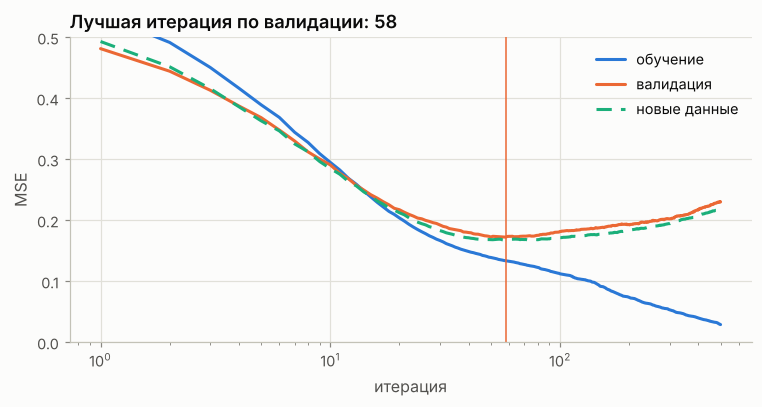

MSE на новых данных: при остановке 0.1680, после 500 деревьев 0.2176, лучшее возможное 0.1676
early_stopping_rounds=30: лучшая итерация 58 деревьев оставлено 58


In [13]:
Xs, ys = datasets.regression_1d(kind="sine", n=300, noise=0.4, seed=7)
X_tr, X_val, y_tr, y_val = datasets.train_test_split(Xs, ys, test_size=0.3, seed=0)
Xnew, ynew = datasets.regression_1d(kind="sine", n=500, noise=0.4, seed=107)
gb = GBRegressor(n_estimators=500, learning_rate=0.1, max_depth=2).fit(X_tr, y_tr, eval_set=(X_val, y_val))
val = 2 * np.array(gb.history_["eval"])  # history хранит ½·MSE
trn = 2 * np.array(gb.history_["train"])
new = [mse(ynew, gb.predict(Xnew, n_iter=m)) for m in range(501)]
best = int(np.argmin(val))
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.semilogx(range(1, 501), trn[1:], color=style.ROLE["train"], label="обучение")
ax.semilogx(range(1, 501), val[1:], color=style.ROLE["valid"], label="валидация")
ax.semilogx(range(1, 501), new[1:], color=style.ROLE["test"], ls=(0, (5, 3)), label="новые данные")
ax.axvline(best, color=style.ROLE["valid"], lw=1)
ax.set(xlabel="итерация", ylabel="MSE", ylim=(0, 0.5), title=f"Лучшая итерация по валидации: {best}")
ax.legend()
plt.show()
print(f"MSE на новых данных: при остановке {new[best]:.4f}, после 500 деревьев {new[500]:.4f}, лучшее возможное {min(new):.4f}")

es = GBRegressor(n_estimators=500, learning_rate=0.1, max_depth=2, early_stopping_rounds=30).fit(X_tr, y_tr, eval_set=(X_val, y_val))
print("early_stopping_rounds=30: лучшая итерация", es.best_iteration_, "деревьев оставлено", es.n_trees_)

## 9. Лотерея разбиения: одна валидация против кросс-валидации

40 случайных разбиений 80 точек: валидация из 20 точек и 5-блочная CV. Насколько гуляют оценка и выбранная глубина?

глубина 4: одно разбиение 0.184…0.515 (ст. откл. 0.084), CV ст. откл. 0.021


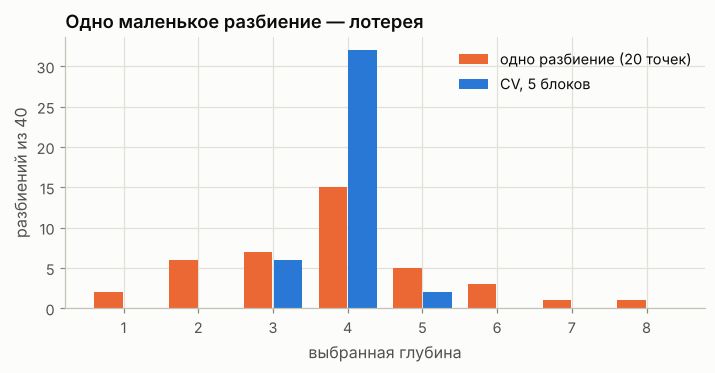

In [14]:
Xk, yk = datasets.regression_1d(kind="sine", n=80, noise=0.4, seed=7)
Xkt, ykt = datasets.regression_1d(kind="sine", n=400, noise=0.4, seed=107)
Hs, Cs = [], []
for sd in range(1, 41):
    p = np.array(Mulberry32(sd).permutation(80))
    va, trn_ = p[:20], p[20:]
    Hs.append([mse(yk[va], RegressionTree(max_depth=d).fit(Xk[trn_], -yk[trn_]).predict(Xk[va])) for d in range(1, 9)])
    fold = np.empty(80, dtype=int)
    fold[p] = np.arange(80) % 5
    Cs.append([np.mean([mse(yk[fold == j], RegressionTree(max_depth=d).fit(Xk[fold != j], -yk[fold != j]).predict(Xk[fold == j])) for j in range(5)]) for d in range(1, 9)])
Hs, Cs = np.array(Hs), np.array(Cs)
print(f"глубина 4: одно разбиение {Hs[:, 3].min():.3f}…{Hs[:, 3].max():.3f} (ст. откл. {Hs[:, 3].std():.3f}), CV ст. откл. {Cs[:, 3].std():.3f}")
pick_h = np.bincount(Hs.argmin(1) + 1, minlength=9)[1:]
pick_c = np.bincount(Cs.argmin(1) + 1, minlength=9)[1:]
fig, ax = plt.subplots(figsize=(7.5, 3.2))
ax.bar(np.arange(1, 9) - 0.2, pick_h, width=0.38, color=style.ORANGE, label="одно разбиение (20 точек)")
ax.bar(np.arange(1, 9) + 0.2, pick_c, width=0.38, color=style.BLUE, label="CV, 5 блоков")
ax.set(xlabel="выбранная глубина", ylabel="разбиений из 40", title="Одно маленькое разбиение — лотерея")
ax.legend()
plt.show()

## 10. k-блочная кросс-валидация и правило одной стандартной ошибки

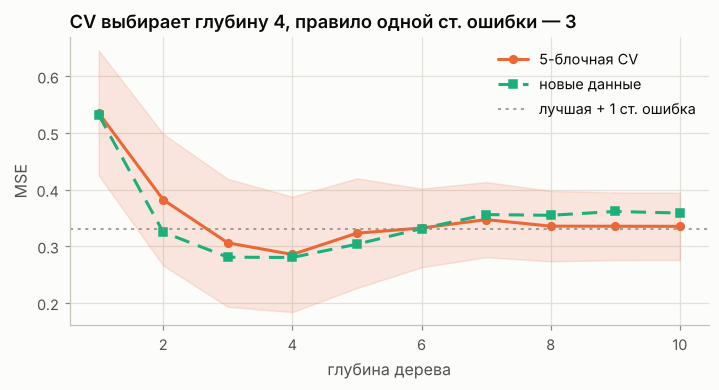

порог 0.331: глубина 3 (CV 0.306); на новых данных 0.281 против 0.280


scikit-learn, глубина 4: CV MSE = 0.314 ± 0.076 (другое перемешивание — другое число)


In [15]:
perm = Mulberry32(0).permutation(len(yk))
fold = np.empty(len(yk), dtype=int)
fold[perm] = np.arange(len(yk)) % 5
cv_mean, cv_std, test_err = [], [], []
for d in range(1, 11):
    sc = [mse(yk[fold == j], RegressionTree(max_depth=d).fit(Xk[fold != j], -yk[fold != j]).predict(Xk[fold == j])) for j in range(5)]
    cv_mean.append(np.mean(sc))
    cv_std.append(np.std(sc))
    test_err.append(mse(ykt, RegressionTree(max_depth=d).fit(Xk, -yk).predict(Xkt)))
cv_mean, cv_std = np.array(cv_mean), np.array(cv_std)
fig, ax = plt.subplots(figsize=(7.5, 3.4))
ax.fill_between(range(1, 11), cv_mean - cv_std, cv_mean + cv_std, color=style.ORANGE, alpha=0.15)
ax.plot(range(1, 11), cv_mean, marker="o", color=style.ORANGE, label="5-блочная CV")
ax.plot(range(1, 11), test_err, marker="s", color=style.AQUA, ls=(0, (5, 3)), label="новые данные")
best = int(np.argmin(cv_mean))
thr = cv_mean[best] + cv_std[best] / np.sqrt(5)
one_se = int(np.argmax(cv_mean <= thr)) + 1
ax.axhline(thr, color=style.MUTED, ls=(0, (2, 3)), lw=1, label="лучшая + 1 ст. ошибка")
ax.set(xlabel="глубина дерева", ylabel="MSE", title=f"CV выбирает глубину {best + 1}, правило одной ст. ошибки — {one_se}")
ax.legend()
plt.show()
print(f"порог {thr:.3f}: глубина {one_se} (CV {cv_mean[one_se - 1]:.3f}); на новых данных {test_err[one_se - 1]:.3f} против {test_err[best]:.3f}")

from sklearn.model_selection import KFold, cross_val_score
from sklearn.tree import DecisionTreeRegressor

sk = -cross_val_score(DecisionTreeRegressor(max_depth=4), Xk, yk, cv=KFold(5, shuffle=True, random_state=0), scoring="neg_mean_squared_error")
print(f"scikit-learn, глубина 4: CV MSE = {sk.mean():.3f} ± {sk.std():.3f} (другое перемешивание — другое число)")

## 11. Утечка при отборе признаков

In [16]:
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

rng = Mulberry32(42)
Xn = np.array([[rng.normal() for _ in range(1000)] for _ in range(60)])
yn = np.array([rng.normal() for _ in range(60)])
cv = KFold(5, shuffle=True, random_state=0)
top = SelectKBest(f_regression, k=10).fit(Xn, yn).get_support()
wrong = cross_val_score(LinearRegression(), Xn[:, top], yn, cv=cv, scoring="r2")
right = cross_val_score(make_pipeline(SelectKBest(f_regression, k=10), LinearRegression()), Xn, yn, cv=cv, scoring="r2")
print(f"с утечкой:  R² = {wrong.mean():.3f}")
print(f"без утечки: R² = {right.mean():.3f}")

с утечкой:  R² = 0.426
без утечки: R² = -0.208


То же своими руками, как в виджете: блоки из `Mulberry32(0)`, $R^2$ по всем прогнозам вне блоков, $k = 1…20$.

k = 10: с утечкой R² = 0.318, без утечки R² = -0.488


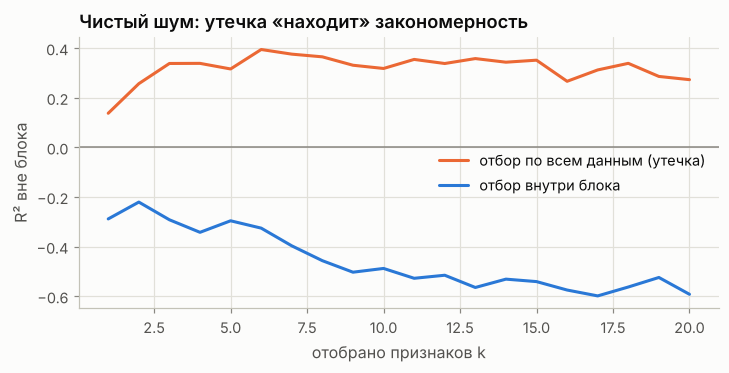

In [17]:
fold_l = np.empty(60, dtype=int)
fold_l[Mulberry32(0).permutation(60)] = np.arange(60) % 5


def top_k(Xa, ya, k):
    Xc, yc = Xa - Xa.mean(0), ya - ya.mean()
    return np.argsort(-np.abs(Xc.T @ yc) / np.sqrt((Xc**2).sum(0) * (yc**2).sum()), kind="stable")[:k]


def ols(Xa, ya, Xb):
    w = np.linalg.lstsq(np.c_[np.ones(len(Xa)), Xa], ya, rcond=None)[0]
    return np.c_[np.ones(len(Xb)), Xb] @ w


def r2_all(pred):
    return 1 - np.sum((yn - pred) ** 2) / np.sum((yn - yn.mean()) ** 2)


ks = range(1, 21)
r2_leak, r2_ok = [], []
for k in ks:
    S = top_k(Xn, yn, k)
    pw, pr = np.zeros(60), np.zeros(60)
    for j in range(5):
        trm, vam = fold_l != j, fold_l == j
        pw[vam] = ols(Xn[trm][:, S], yn[trm], Xn[vam][:, S])
        own = top_k(Xn[trm], yn[trm], k)
        pr[vam] = ols(Xn[trm][:, own], yn[trm], Xn[vam][:, own])
    r2_leak.append(r2_all(pw))
    r2_ok.append(r2_all(pr))
print(f"k = 10: с утечкой R² = {r2_leak[9]:.3f}, без утечки R² = {r2_ok[9]:.3f}")
fig, ax = plt.subplots(figsize=(7.5, 3.2))
ax.plot(ks, r2_leak, color=style.ORANGE, label="отбор по всем данным (утечка)")
ax.plot(ks, r2_ok, color=style.BLUE, label="отбор внутри блока")
ax.axhline(0, color=style.MUTED, lw=1)
ax.set(xlabel="отобрано признаков k", ylabel="R² вне блока", title="Чистый шум: утечка «находит» закономерность")
ax.legend()
plt.show()

## 12. Временной ряд: случайные блоки против проверки по времени

10 лет помесячных продаж: рост, сезонность, шум. Дерево по номеру месяца; будущее — следующие 24 месяца.

глубина 6: случайные блоки 0.230, по времени 0.545, будущее 0.430


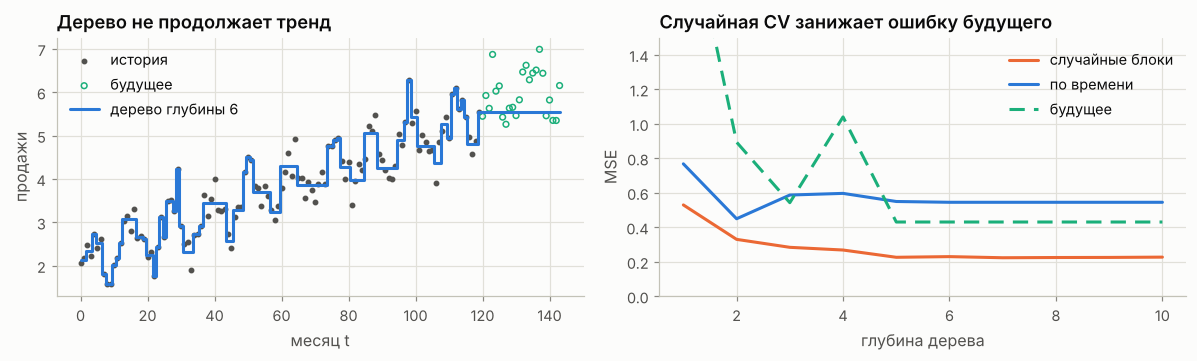

In [18]:
from sklearn.model_selection import TimeSeriesSplit

r = Mulberry32(5)
t_m = np.arange(144)
sales = np.array([2 + 0.03 * ti + 0.6 * np.sin(2 * np.pi * ti / 12) + 0.3 * r.normal() for ti in t_m])
T_m = t_m.reshape(-1, 1).astype(float)
fold_t = np.empty(120, dtype=int)
fold_t[Mulberry32(0).permutation(120)] = np.arange(120) % 5
hist = np.arange(120)


def err_t(tr_i, te_i, d):
    return mse(sales[te_i], RegressionTree(max_depth=d).fit(T_m[tr_i], -sales[tr_i]).predict(T_m[te_i]))


rnd_cv, time_cv, fut = [], [], []
for d in range(1, 11):
    rnd_cv.append(np.mean([err_t(hist[fold_t != j], hist[fold_t == j], d) for j in range(5)]))
    time_cv.append(np.mean([err_t(tr_i, te_i, d) for tr_i, te_i in TimeSeriesSplit(n_splits=5).split(hist)]))
    fut.append(err_t(hist, np.arange(120, 144), d))
print(f"глубина 6: случайные блоки {rnd_cv[5]:.3f}, по времени {time_cv[5]:.3f}, будущее {fut[5]:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].scatter(t_m[:120], sales[:120], s=8, color=style.ROLE["data"], label="история")
axes[0].scatter(t_m[120:], sales[120:], s=14, facecolors="none", edgecolors=style.AQUA, label="будущее")
axes[0].step(t_m, RegressionTree(max_depth=6).fit(T_m[:120], -sales[:120]).predict(T_m), where="mid", color=style.BLUE, label="дерево глубины 6")
axes[0].set(xlabel="месяц t", ylabel="продажи", title="Дерево не продолжает тренд")
axes[0].legend()
axes[1].plot(range(1, 11), rnd_cv, color=style.ORANGE, label="случайные блоки")
axes[1].plot(range(1, 11), time_cv, color=style.BLUE, label="по времени")
axes[1].plot(range(1, 11), fut, color=style.AQUA, ls=(0, (5, 3)), label="будущее")
axes[1].set(xlabel="глубина дерева", ylabel="MSE", ylim=(0, 1.5), title="Случайная CV занижает ошибку будущего")
axes[1].legend()
fig.tight_layout()
plt.show()

## Упражнения

1. Модель A: 0.45 / 0.47, модель B: 0.02 / 0.38 (обучение / валидация), шум 0.12. Диагноз?
2. Посчитайте смещение² и разброс для выстрелов (1, 1), (1, −1), (3, 0).
3. Как меняются смещение и разброс дерева глубины 8 при росте n с 30 до 120?
4. Найдите лучшее M бустинга при ν = 0.3 и ν = 0.05.
5. Разброс среднего при ρ = 0.3 и ρ = 0.1 для B = 1…1000.
6. Ранняя остановка для ν ∈ {1, 0.3, 0.1, 0.03}.
7. Обычная и повторённая кросс-валидация: разброс оценок.
8. Что не так, если CV использовали и для выбора, и для итоговой оценки?
9. Утечка при отборе признаков для k = 5, 10, 50.
10. Оптимизм константы: ошибки на обучении и на новом объекте при n = 5, σ² = 1 — формулой и симуляцией.
11. Сжатие листа: μ = 0.5, σ = 1, n = 10 — найдите λ*, c* и ошибку; проверьте симуляцией.
12. Правило одной стандартной ошибки для 10-блочной CV (данные шага 10).
13. Временной ряд: как меняется разрыв между случайной CV и будущим, если убрать тренд (наклон 0)?

<details><summary>Решения</summary>

`python lessons/lesson_1_4/exercises/solutions.py`
</details>